In [ ]:
from google.colab import drive
drive.mount('/content/drive');
!apt-get update -qq
!apt-get install -y -qq stockfish
!pip install -q python-chess stockfish opencv-python-headless mediapipe scikit-learn pandas matplotlib seaborn moviepy joblib
import shutil,sys
from stockfish import Stockfish
import chess,cv2,pandas as pd, mediapipe as mp
print("The environment checking is happening...");
print("Python's version:->",sys.version.split()[0]);
print("python-chess:->",getattr(chess,"__version__","n/a"));
print("OpenCV:",cv2.__version__)
print("Pandas:->",pd.__version__)
print("Mediapipe:->", mp.__version__)
stockfish_path=shutil.which("stockfish") or "/usr/games/stockfish"
print("The stockfish binary path is",stockfish_path);
try:
  sf=Stockfish(path=stockfish_path,parameters={"Threads":2,"Hash":32})
  print("Stockfish initialized:",sf.is_alive())
  print("Stockfish's sample params:",sf.get_parameters().get("Threads","n/a"))
except Exception as e:
  print("Stockfish could not be initialised at the moment, error!:",e)
try:
    import torch
    print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
except Exception:
    print("Torch not installed — OK for now.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
The environment checking is happening...
Python's version:-> 3.12.12
python-chess:-> 1.11.2
OpenCV: 4.12.0
Pandas:-> 2.2.2
Mediapipe:-> 0.10.14
The stockfish binary path is /usr/games/stockfish
Stockfish could not be initialised at the moment, error!: 'Stockfish' object has no attribute 'is_alive'
Torch: 2.8.0+cu126 | CUDA: True


In [ ]:
import chess;
import chess.pgn;
from stockfish import Stockfish;
import pandas as pd;
import io;
print("The current scenario in this cell is about setting up the feature Extractions Module");
stockfish_path="/usr/games/stockfish";
sf=Stockfish(path=stockfish_path,parameters={"Threads":2,"Hash":64});
sf.update_engine_parameters({"UCI_LimitStrength":False,"UCI_Elo":2500});

class ChessFeatureExtractor:
  def __init__(self,engine):
    self.engine=engine;
  def evaluate_position(self,board):
    fen=board.fen();
    self.engine.set_fen_position(fen);
    eval_info=self.engine.get_evaluation();
    if eval_info["type"]=="cp":
      return eval_info["value"];
    elif eval_info["type"]=="mate":
      return 10000 if eval_info["value"]>0 else -10000;
    return 0;
  def move_rank(self,board,move_uci):
    fen=board.fen();
    self.engine.set_fen_position(fen)
    top_moves=self.engine.get_top_moves(3)
    for rank,move in enumerate(top_moves,start=1):
      if move["Move"]==move_uci:
        return rank;
    return 4;
  def extract_features_from_game(self,pgn_string):
    game=chess.pgn.read_game(io.StringIO(pgn_string));
    board=game.board();
    data=[];
    move_number=1;
    for move in game.mainline_moves():
      eval_before=self.evaluate_position(board);
      move_uci=move.uci();
      move_rank=self.move_rank(board,move_uci);
      board.push(move);
      eval_after=self.evaluate_position(board);
      eval_change=eval_after-eval_before;
      data.append({
          "move_number":move_number,
          "move":move_uci,
          "eval_before":eval_before,
          "eval_after":eval_after,
          "eval_change":eval_change,
          "move_rank":move_rank
      });
      move_number+=1;
    return pd.DataFrame(data);

pgn_text="""
[Event "Example Game"]
[Site "?"]
[Date "2025.11.06"]
[Round "?"]
[White "Human"]
[Black "Engine"]
[Result "*"]

1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O Be7 6. Re1 b5 7. Bb3 d6 8. c3 O-O 9. h3 *
""";

extractor=ChessFeatureExtractor(sf);
df_features=extractor.extract_features_from_game(pgn_text);
print("Feature extraction completed. Sample data:");
print(df_features.head());


The current scenario in this cell is about setting up the feature Extractions Module
Feature extraction completed. Sample data:
   move_number  move  eval_before  eval_after  eval_change  move_rank
0            1  e2e4           37          49           12          2
1            2  e7e5           35          50           15          1
2            3  g1f3           42          29          -13          1
3            4  b8c6           47          56            9          1
4            5  f1b5           55          62            7          1


In [ ]:
import random;
print("The current scenario in this cell is about combining multiple games and labelling the dataset");
extractor=ChessFeatureExtractor(sf);
human_pgn="""
[Event "Human Example"]
[Site "?"]
[Date "2025.11.06"]
[Round "?"]
[White "HumanPlayer"]
[Black "HumanOpponent"]
[Result "*"]

1. e4 e5 2. Nf3 Nc6 3. Bc4 Nf6 4. Ng5 d5 5. exd5 Nxd5 6. d3 Be7 7. Nf3 O-O 8. Nc3 Nb6 9. Bb3 Bg4 10. h3 *
""";
#any sorted engine game..
engine_pgn="""
[Event "Engine Example"]
[Site "?"]
[Date "2025.11.06"]
[Round "?"]
[White "Stockfish"]
[Black "Leela"]
[Result "*"]

1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O Be7 6. Re1 b5 7. Bb3 d6 8. c3 O-O 9. h3 Nb8 10. d4 Nbd7 *
""";

df_human=extractor.extract_features_from_game(human_pgn);
df_engine=extractor.extract_features_from_game(engine_pgn);
df_human["label"]=1;  # human
df_engine["label"]=0; # engine
df_all=pd.concat([df_human,df_engine],ignore_index=True);
df_all=df_all.sample(frac=1,random_state=42).reset_index(drop=True);
print("The combination OF the dataset has been done successfully. Sample rows are hereby given to you:-");
print(df_all.head(10));
print("\nColumns available:",list(df_all.columns));
print("\nLabel distribution:");
print(df_all["label"].value_counts());
df_all.to_csv("/content/drive/MyDrive/chess_cheat_detection_dataset.csv",index=False);
print("\nDataset saved to Drive at -> /content/drive/MyDrive/chess_cheat_detection_dataset.csv");

The current scenario in this cell is about combining multiple games and labelling the dataset
The combination OF the dataset has been done successfully. Sample rows are hereby given to you:-
   move_number  move  eval_before  eval_after  eval_change  move_rank  label
0           15  c2c3           60          70           10          2      0
1           18  c6b8           41          57           16          4      0
2            5  f1c4           41          33           -8          3      1
3           14  e8g8         -114         -91           23          1      1
4           12  b7b5           76          78            2          1      0
5            8  g8f6           46          55            9          3      0
6            7  f3g5           28           5          -23          2      1
7            9  e1g1           52          34          -18          1      0
8            6  a7a6           29          73           44          1      0
9           16  d5b6         -112      

Here i will write about training the cheat detection model
The model has been trained successfully
Accuracy of the trained model is:-> 75.0 %


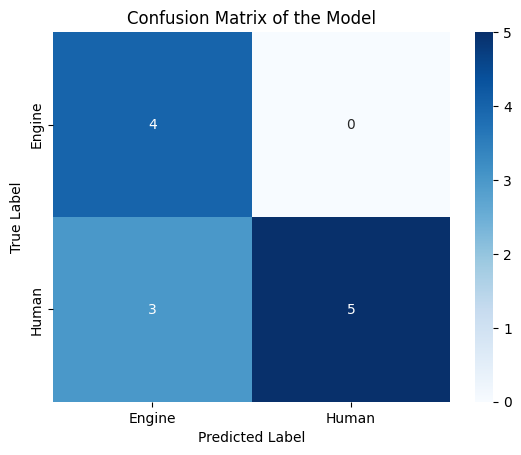


The following is the detailed classification report is as follows:-
              precision    recall  f1-score   support

      Engine       0.57      1.00      0.73         4
       Human       1.00      0.62      0.77         8

    accuracy                           0.75        12
   macro avg       0.79      0.81      0.75        12
weighted avg       0.86      0.75      0.76        12


Model has been saved at -> /content/drive/MyDrive/chess_cheat_detector_model.pkl


In [ ]:
import pandas as pd;
from sklearn.model_selection import train_test_split;
from sklearn.ensemble import RandomForestClassifier;
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report;
import matplotlib.pyplot as plt;
import seaborn as sns;
import joblib;
print("Here i will write about training the cheat detection model");
df=pd.read_csv("/content/drive/MyDrive/chess_cheat_detection_dataset.csv");
X=df[["eval_before","eval_after","eval_change","move_rank"]];
y=df["label"];
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42);
model=RandomForestClassifier(n_estimators=100,random_state=42);
model.fit(X_train,y_train);
y_pred=model.predict(X_test);
acc=accuracy_score(y_test,y_pred);
print("The model has been trained successfully");
print("Accuracy of the trained model is:->",round(acc*100,2),"%");
cm=confusion_matrix(y_test,y_pred);
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Engine","Human"],yticklabels=["Engine","Human"]);
plt.title("Confusion Matrix of the Model");
plt.xlabel("Predicted Label");
plt.ylabel("True Label");
plt.show();
print("\nThe following is the detailed classification report is as follows:-");
print(classification_report(y_test,y_pred,target_names=["Engine","Human"]));
joblib.dump(model,"/content/drive/MyDrive/chess_cheat_detector_model.pkl");
print("\nModel has been saved at -> /content/drive/MyDrive/chess_cheat_detector_model.pkl");

In [ ]:
import time;
import chess;
from stockfish import Stockfish;
import joblib;
import numpy as np;
print("The present scenario in this cell is about simulating real-time cheat detection");
model=joblib.load("/content/drive/MyDrive/chess_cheat_detector_model.pkl");
sf=Stockfish("/usr/games/stockfish",parameters={"Threads":2,"Hash":64});

def evaluate_position(fen):
  sf.set_fen_position(fen);
  eval_info=sf.get_evaluation();
  if eval_info["type"]=="cp":
    return eval_info["value"];
  elif eval_info["type"]=="mate":
    return 10000 if eval_info["value"]>0 else -10000;
  return 0;
def move_rank(fen,move_uci):
  sf.set_fen_position(fen);
  top_moves=sf.get_top_moves(3);
  for rank,move in enumerate(top_moves,start=1):
    if move["Move"]==move_uci:
      return rank;
  return 4;

def detect_cheat_realtime(moves):
  board=chess.Board();
  print("The real-time cheat detection simulation has started\n");
  for i,move_str in enumerate(moves,start=1):
    fen_before=board.fen();
    eval_before=evaluate_position(fen_before);
    rank=move_rank(fen_before,move_str);
    board.push_uci(move_str);
    eval_after=evaluate_position(board.fen());
    eval_change=eval_after-eval_before;
    X_live=pd.DataFrame([[eval_before,eval_after,eval_change,rank]],
                    columns=["eval_before","eval_after","eval_change","move_rank"]);
    pred=model.predict(X_live)[0];
    prob=model.predict_proba(X_live)[0][1];
    label="Human-like" if pred==1 else "Engine-like";
    print("Move",i,":",move_str,"| Rank=",rank,"| ΔEval=",eval_change,"| Prediction:",label,"| Confidence=",round(prob*100,1),"%");
    time.sleep(0.7);

test_moves=["e2e4","e7e5","g1f3","b8c6","f1b5","a7a6","b5a4","g8f6"];
detect_cheat_realtime(test_moves);


The present scenario in this cell is about simulating real-time cheat detection
The real-time cheat detection simulation has started

Move 1 : e2e4 | Rank= 2 | ΔEval= 2 | Prediction: Human-like | Confidence= 70.0 %
Move 2 : e7e5 | Rank= 2 | ΔEval= 23 | Prediction: Engine-like | Confidence= 1.0 %
Move 3 : g1f3 | Rank= 1 | ΔEval= -20 | Prediction: Human-like | Confidence= 66.0 %
Move 4 : b8c6 | Rank= 1 | ΔEval= 10 | Prediction: Engine-like | Confidence= 0.0 %
Move 5 : f1b5 | Rank= 2 | ΔEval= 2 | Prediction: Engine-like | Confidence= 0.0 %
Move 6 : a7a6 | Rank= 1 | ΔEval= 9 | Prediction: Engine-like | Confidence= 0.0 %
Move 7 : b5a4 | Rank= 1 | ΔEval= -1 | Prediction: Engine-like | Confidence= 0.0 %
Move 8 : g8f6 | Rank= 2 | ΔEval= 6 | Prediction: Engine-like | Confidence= 1.0 %


In [ ]:
import requests;
import pandas as pd;
print("Fetch my chess.com cosmoscorona10 games");
username="cosmoscorona10";
base_url=f"https://api.chess.com/pub/player/{username}/games/archives";
headers={"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"};

response=requests.get(base_url,headers=headers);
if response.status_code==200:
  archives=response.json()["archives"];
  print("Archives found:",len(archives));
  print("The latest archive url is",archives[-1]);
else:
  print("error",response.status_code);
  archives=[];

pgn_games="";
if archives:
  latest_archive_url=archives[-1];
  data=requests.get(latest_archive_url,headers=headers).json();
  for g in data["games"]:
    if "pgn" in g:
      pgn_games+=g["pgn"]+"\n\n";
  print("Number of games fetched:",len(data["games"]));
else:
  print("No archives available for this user.");

if pgn_games.strip()!="":
  file_path="/content/drive/MyDrive/chess_com_games_cosmoscorona10.pgn";
  with open(file_path,"w") as f:
    f.write(pgn_games);
  print("Games have been saved successfully to ->",file_path);
else:
  print("No PGN data found to save.");


Fetch my chess.com cosmoscorona10 games
Archives found: 21
The latest archive url is https://api.chess.com/pub/player/cosmoscorona10/games/2025/11
Number of games fetched: 35
Games have been saved successfully to -> /content/drive/MyDrive/chess_com_games_cosmoscorona10.pgn


In [ ]:
import io;
print("Now let us talk about extracting features from my real chess.com account games");
pgn_file="/content/drive/MyDrive/chess_com_games_cosmoscorona10.pgn";
with open(pgn_file,"r") as f:
  pgn_data=f.read();

games=pgn_data.strip().split("\n\n\n");
print("Total games detected in PGN file:",len(games));

extractor=ChessFeatureExtractor(sf);
all_features=[];

for i,game_text in enumerate(games,start=1):
  try:
    df_game=extractor.extract_features_from_game(game_text);
    df_game["label"]=1;
    all_features.append(df_game);
    print("Processed game",i,"with",len(df_game),"moves");
  except Exception as e:
    print("Skipping game",i,"due to error:",e);

if len(all_features)>0:
  df_total=pd.concat(all_features,ignore_index=True);
  file_path="/content/drive/MyDrive/chess_cosmoscorona10_features.csv";
  df_total.to_csv(file_path,index=False);
  print("\nFeature extraction complete. All data saved to ->",file_path);
  print("Total extracted moves:",len(df_total));
else:
  print("No features extracted — verify PGN file content.");


Now let us talk about extracting features from my real chess.com account games
Total games detected in PGN file: 35
Processed game 1 with 68 moves
Processed game 2 with 82 moves
Processed game 3 with 60 moves
Processed game 4 with 55 moves
Processed game 5 with 41 moves
Processed game 6 with 74 moves
Processed game 7 with 104 moves
Processed game 8 with 79 moves
Processed game 9 with 49 moves
Processed game 10 with 69 moves
Processed game 11 with 126 moves
Processed game 12 with 94 moves
Processed game 13 with 70 moves
Processed game 14 with 24 moves
Processed game 15 with 20 moves
Processed game 16 with 66 moves
Processed game 17 with 63 moves
Processed game 18 with 62 moves
Processed game 19 with 45 moves
Processed game 20 with 87 moves
Processed game 21 with 89 moves
Processed game 22 with 46 moves
Processed game 23 with 75 moves
Processed game 24 with 68 moves
Processed game 25 with 82 moves
Processed game 26 with 25 moves
Processed game 27 with 48 moves
Processed game 28 with 56 m